# STAC with pyramids (offline)

`pyramids.stac` connects pyramids to the SpatioTemporal Asset Catalog ecosystem — reading assets, stacking cubes, reading extension metadata, building VRT mosaics, writing STAC Items, GeoParquet round-trips, and cloud signers — all **GDAL-native** and **duck-typed** (raw STAC JSON dicts work; `pystac` is never imported by pyramids).

This notebook is **fully offline**: it builds small local rasters and wraps them as raw STAC item dicts, so every cell runs without network access. The client/search and download paths (which need a live catalog) are shown as code in the final section but not executed. See the [STAC tutorial](../../tutorials/stac.md) and [reference](../../reference/stac/index.md).

## Setup

Build a temp workspace and a couple of small local rasters to stand in for STAC assets.

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

import numpy as np

from pyramids.dataset import Dataset, DatasetCollection
from pyramids.stac import (
    AWSRequesterPaysSigner,
    BearerTokenSigner,
    build_vrt_from_stac,
    from_geoparquet,
    read_extension_metadata,
    resolved_href,
    to_geoparquet,
    which_engine,
)

WORK = Path(tempfile.mkdtemp(prefix='pyramids_stac_nb_'))


def write_band(name, value, *, cell=10.0, shape=(4, 4), top_left=(600000.0, 5300000.0)):
    """Write a constant uint16 EPSG:32630 raster (nodata 0) and return its path."""
    ds = Dataset.create_from_array(
        np.full(shape, value, dtype='uint16'),
        top_left_corner=top_left,
        cell_size=cell,
        epsg=32630,
        no_data_value=0,
    )
    path = str(WORK / f'{name}.tif')
    ds.to_file(path)
    return path


# One scene with a 10 m B04 and a 20 m B05 (the classic Sentinel-2 mixed-resolution case)
b04 = write_band('B04', 1)
b05 = write_band('B05', 2, cell=20.0, shape=(2, 2))
items = [
    {
        'id': 'scene-0',
        'bbox': [0.0, 0.0, 1.0, 1.0],
        'assets': {'B04': {'href': b04}, 'B05': {'href': b05}},
    }
]
print('workspace:', WORK)

workspace: /tmp/pyramids_stac_nb_p_ultzwk


## Read extension metadata without opening the file

`read_extension_metadata` turns a STAC Item's `proj` / `raster` / `eo` fields into a grid + band-metadata dict — CRS, GDAL geotransform, shape, nodata/scale, band names — with **zero file I/O** (the way stackstac / odc-stac / rio-tiler do).

In [2]:
item_md = {
    'properties': {'proj:epsg': 32633},
    'assets': {
        'B04': {
            'href': 's3://bucket/B04.tif',
            'proj:shape': [10980, 10980],
            'proj:transform': [10.0, 0.0, 600000.0, 0.0, -10.0, 5300040.0],
            'raster:bands': [{'nodata': 0, 'scale': 0.0001}],
            'eo:bands': [{'name': 'B04', 'common_name': 'red'}],
        }
    },
}
meta = read_extension_metadata(item_md, 'B04')
{k: meta[k] for k in ('crs', 'geotransform', 'shape', 'band_names')}

{'crs': 'EPSG:32633',
 'geotransform': (600000.0, 10.0, 0.0, 5300040.0, 0.0, -10.0),
 'shape': [10980, 10980],
 'band_names': ['B04']}

## Build a cube — `from_stac`

A single asset key → one band-set per timestep; a **list** of keys → a band axis (stackstac/odc-stac style). `which_engine` previews the reader without opening.

In [3]:
which_engine(items[0], 'B04')

'gdal'

In [4]:
# single asset -> time stack
single = DatasetCollection.from_stac(items, asset='B04')
single.time_length, single.datasets[0].band_count

(1, 1)

In [5]:
# multiple assets -> band axis; align=True resamples the 20 m B05 onto B04's 10 m grid
cube = DatasetCollection.from_stac(items, asset=['B04', 'B05'], align=True)
ds0 = cube.datasets[0]
ds0.band_count, ds0.band_names, ds0.read_array().shape

(2, ['B04', 'B05'], (2, 4, 4))

Plot band 0 (B04) of the aligned `cube` to see the band-axis collection built from the two local STAC assets.

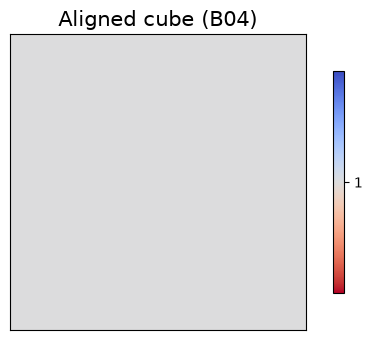

In [6]:
cube.plot(band=0, title="Aligned cube (B04)")

### Mosaic same-overpass tiles — `groupby='solar_day'`

Items sharing a solar day fuse into one timestep (first-valid mosaic).

In [7]:
def scene(name, value, when):
    path = write_band(name, value)
    return {
        'id': name,
        'bbox': [0.0, 0.0, 1.0, 1.0],
        'properties': {'datetime': when},
        'assets': {'data': {'href': path}},
    }


day_items = [
    scene('t0', 1, '2021-06-01T10:00:00Z'),
    scene('t1', 2, '2021-06-01T10:00:30Z'),  # same solar day as t0
    scene('t2', 3, '2021-06-05T10:00:00Z'),
]
daily = DatasetCollection.from_stac(day_items, asset='data', groupby='solar_day')
daily.time_length  # two distinct solar days

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/osgeo/gdal.py:13574: RuntimeWarning: Band data type of UInt16 cannot represent the specified NoData value of nan
  return _gdal.BuildVRTInternalObjects(*args)


2

Plot the first time slice of the `daily` collection — the solar-day grouping fused same-overpass scenes into one
mosaic per day.

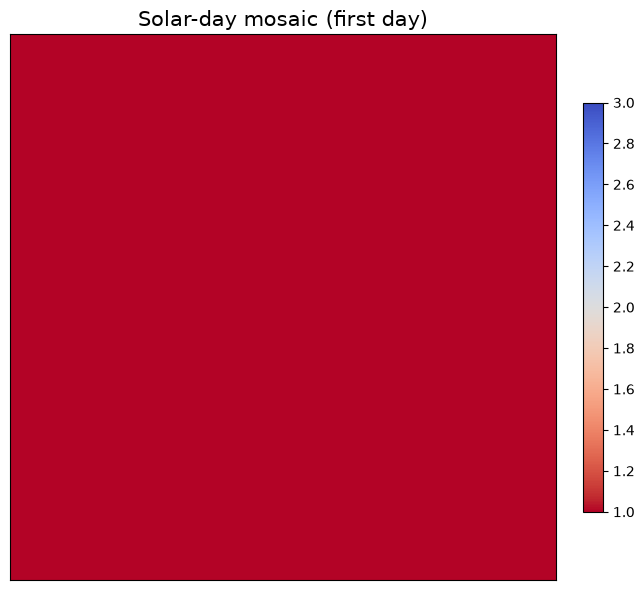

In [8]:
daily.plot(band=0, title="Solar-day mosaic (first day)")

## Write a raster back out as a STAC Item — `to_stac_item`

Describe a `Dataset` as a STAC Item dict (proj + raster extensions); `pystac` not required. The footprint is the bounds reprojected to EPSG:4326.

In [9]:
ds = Dataset.read_file(b04)
item = ds.to_stac_item(
    'scene-0',
    asset_href=b04,
    asset_media_type='image/tiff; application=geotiff',
    datetime='2021-06-01T00:00:00Z',
)
item['properties']['proj:code'], [round(c, 4) for c in item['bbox']]

('EPSG:32630', [-1.6634, 47.8452, -1.6629, 47.8456])

## Serialize items ↔ GeoParquet (optional `[parquet]` extra)

`to_geoparquet` / `from_geoparquet` round-trip an ItemCollection losslessly. Guarded so the notebook still runs without pyarrow.

In [10]:
try:
    pq = WORK / 'catalog.parquet'
    to_geoparquet([item], pq)
    restored = from_geoparquet(pq)
    print(
        'round-trip id:',
        restored[0]['id'],
        '| proj:code:',
        restored[0]['properties']['proj:code'],
    )
except ImportError:
    print("pyarrow ([parquet] extra) not installed - skipping GeoParquet round-trip")

round-trip id: scene-0 | proj:code: EPSG:32630


## Mosaic an asset across items — `build_vrt_from_stac`

Stitch one asset across many items into a lazy GDAL VRT `Dataset` (read on demand).

In [11]:
a = write_band('tileA', 10, top_left=(600000.0, 5300000.0))
b = write_band('tileB', 20, top_left=(600040.0, 5300000.0))  # abuts tileA to the east
mosaic_items = [{'assets': {'data': {'href': a}}}, {'assets': {'data': {'href': b}}}]
vrt = build_vrt_from_stac(mosaic_items, asset='data')
arr = vrt.read_array()
arr.shape, int(arr[0, 0]), int(arr[0, -1])  # union 4x8; left=tileA(10), right=tileB(20)

((4, 8), 10, 20)

Plot the lazy `vrt` mosaic to see the two abutting tiles stitched into one raster — tileA (10) on the left,
tileB (20) on the right.

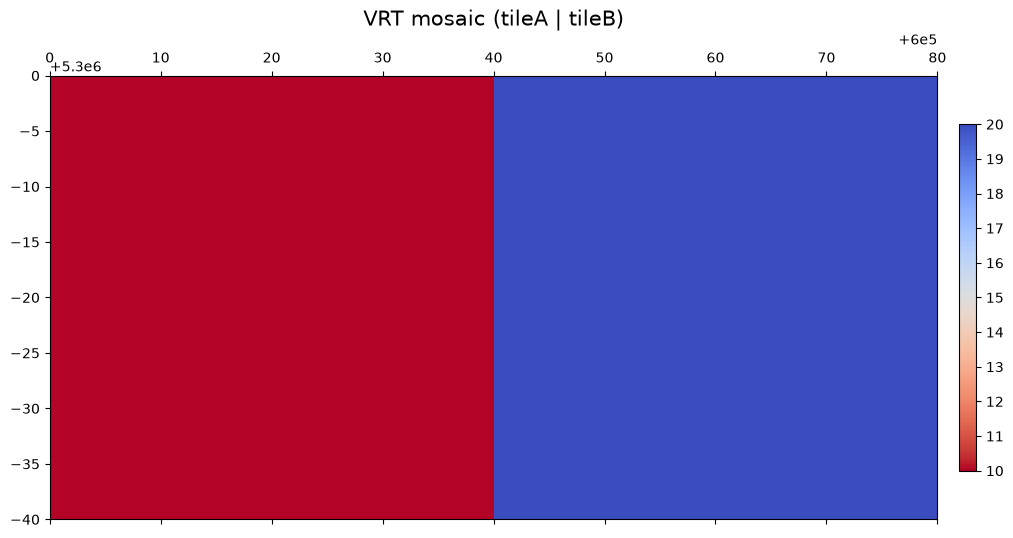

In [12]:
vrt.plot(band=0, title="VRT mosaic (tileA | tileB)")

## Signers (offline)

Each signer applies credentials at one of three boundaries — the search request, the asset href, and/or the GDAL read env. Below: constructing them and inspecting the hooks, no network.

In [13]:
# AWS Requester-Pays: only a GDAL env (no href/request rewrite)
AWSRequesterPaysSigner(region='us-west-2').gdal_env()

{'AWS_REGION': 'us-west-2',
 'AWS_DEFAULT_REGION': 'us-west-2',
 'AWS_REQUEST_PAYER': 'requester',
 'GDAL_DISABLE_READDIR_ON_OPEN': 'EMPTY_DIR',
 'CPL_VSIL_CURL_USE_HEAD': 'NO',
 'GDAL_HTTP_MULTIPLEX': 'YES',
 'GDAL_HTTP_VERSION': '2'}

In [14]:
# Bearer token: an Authorization header in the GDAL env
BearerTokenSigner('demo-token').gdal_env()

{'GDAL_HTTP_HEADERS': 'Authorization: Bearer demo-token'}

In [15]:
# resolved_href returns the (optionally signed) href WITHOUT opening the asset
resolved_href(items[0], 'B04')

'/tmp/pyramids_stac_nb_p_ultzwk/B04.tif'

## Live-catalog paths (network — not executed here)

Against a real STAC API you would search and sign over the network. These need the `[stac]` extra (pystac-client) and a live endpoint, so they are shown but not run:

```python
from pyramids.stac import search
from earthlens.stac import PlanetaryComputerSigner  # PC signing lives in earthlens
from pyramids.dataset import DatasetCollection

items = search(
    'https://earth-search.aws.element84.com/v1', 'sentinel-2-l2a',
    bbox=(11.0, 46.0, 11.2, 46.2), datetime='2023-06/2023-08',
    query={'eo:cloud_cover': {'lt': 20}}, max_items=12,
)
cube = DatasetCollection.from_stac(items, asset=['red', 'green', 'blue'])

# or a point + edge-size convenience cube (Planetary Computer):
cube = DatasetCollection.from_point(
    lat=46.0, lon=11.0, collection='sentinel-2-l2a', bands=['B04', 'B03', 'B02'],
    start_date='2021-06-01', end_date='2021-06-10', edge_size=64, resolution=10,
    signer=PlanetaryComputerSigner(),
)

# download assets to local files (needs the [stac] extra's stac-asset):
from pyramids.stac import download_item
local = download_item(items[0], 'scenes/', include=['B04', 'B03', 'B02'])
```